# Blackbox-LSTM GR predictor on **LA2A** — Local Eval

Companion to [`train_lstm_blackbox_gr.ipynb`](train_lstm_blackbox_gr.ipynb) (this
folder) — the LA2A retarget of the `05_conditioning` learned-frontend GR predictor.
Same `BlackboxGRLSTM` model, and the SAME 9-column streaming metric engine as
[`eval_lstm_gain_prior_ws.ipynb`](eval_lstm_gain_prior_ws.ipynb) /
`06_output/eval_lstm_gain_prior_ws.ipynb`, so LA2A numbers drop straight into the
cross-model comparison. The model predicts a **GR curve** from dry audio + knobs; wet
audio is **reconstructed** as `dry · 10^(GR_dB/20)` before scoring, exactly as the
`05_conditioning` blackbox eval does — so GR-predictor and wet-audio models stay
directly comparable.

Two things differ from the diffssl blackbox eval:

- **GR on-the-fly.** Instead of loading `gr_curves/*.pt`, the target GR is recomputed
  per segment from `(dry, wet)` with the exact export function
  `src.dsp_torch.gain_reduction_db(·, 1024)` + a 1023-sample lookback — bit-identical to
  the exported curve (see `dataset_la2a`). No `.pt` files needed.
- **Split = temporal regions, not held-out pairs.** LA2A's 84 recordings each hold one
  setting, so the train notebook splits **within each recording** (`train[0,.8) /
  val[.8,.9) / test[.9,1)`). "Validation" / "test" here therefore mean the `[.8,.9)` /
  `[.9,1)` fraction **regions of every recording** — unseen audio at known settings. Each
  region is streamed statefully (`(lstm_state, frame_context)` carried across chunks; one
  warm-up chunk fed but not scored). There is no external `test_ground_truth/` set for
  LA2A — the SignalTrain corpus is a flat pool of recordings, not a song × setting grid.

```
dry ─ learned Conv frame-encoder (stride 256) ─ dilated temporal Conv stack ─ 1×1 proj
      features → LSTM(8→32) → polynomial-FiLM(knobs[comp_limit, peak_reduction]) → GLU → Linear → gr [dB]
      wet_hat = dry · 10^(gr/20)   (reconstruct for scoring)
```

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# BlackboxGRLSTM needs no nablafx — but the metric-engine self-check (── 6b) imports
# nablafx.evaluation (auraloss). Stub the `rational` / `frechet_audio_distance`
# import-chain deps so that optional `from nablafx...` can't drag in broken wheels.
_rational = types.ModuleType("rational")
_rational.torch = types.ModuleType("rational.torch")
_rational.torch.Rational = type("Rational", (), {})
sys.modules.setdefault("rational", _rational)
sys.modules.setdefault("rational.torch", _rational.torch)
_fad = types.ModuleType("frechet_audio_distance")
_fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules.setdefault("frechet_audio_distance", _fad)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT))                        # `src`
sys.path.insert(0, str(REPO_ROOT / "nablafx"))            # raw ./nablafx/ clone (optional metric verify)
sys.path.insert(0, str(REPO_ROOT / "05_conditioning"))   # model_blackbox_gr, gr_target
sys.path.insert(0, str(REPO_ROOT / "08_la2a"))           # splits_la2a, dataset_la2a
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred")) # eval_helpers

from model_blackbox_gr import BlackboxGRLSTM
from gr_target import GR_DB_MIN, GR_DB_MAX
from splits_la2a import (
    La2aSplitManifest, LA2A_PARAM_ORDER, normalize_la2a_params, region_bounds,
)
from dataset_la2a import discover_la2a_pairs, RMS_WINDOW, SAMPLE_RATE
from eval_helpers import (
    _checkpoint_sort_key, _find_hparams_json, _read_dry_wet_segment,
    _weighted_average_metric_rows, latest_best_checkpoint, list_runs, plot_loss_curves,
)
from src.dsp_torch import gain_reduction_db

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/LA2A"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/la2a_gr_pred_runs"
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB  |  RMS window: {RMS_WINDOW} samples")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR clamp: [-30.0, 5.0] dB  |  RMS window: 1024 samples


In [2]:
# ── 1. List available Blackbox-LSTM GR runs ──────────────────────────

MODEL_TYPE = "la2a_blackbox_gr_lstm_film"   # hparams["model_type"]

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
if available_models_df.empty:
    # fall back to folder-name tag if hparams["model_type"] is missing/older
    available_models_df = runs_df[runs_df["run"].str.contains("blackbox_gr", case=False, na=False)].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_blackbox_gr.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available Blackbox-LSTM GR runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available Blackbox-LSTM GR runs: 2


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,la2a_gr_20260707_205937_la2a_lstm_blackbox_gr_...,la2a_blackbox_gr_lstm_film,NaN,NaN,0,None,2026-07-29 08:49:52.125838041
1,la2a_gr_20260707_233430_la2a_lstm_blackbox_gr_...,la2a_blackbox_gr_lstm_film,200.0,0.520173,4,best-197-24948.ckpt,2026-07-29 08:49:52.189366102


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = None

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = La2aSplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = SPLIT.train_frac, SPLIT.val_frac, SPLIT.test_frac

# normalisation guard — GR range must match the local gr_target.py the model uses
assert tuple(HP["gr_range_db"]) == (GR_DB_MIN, GR_DB_MAX), HP["gr_range_db"]

# LA2A split is temporal WITHIN each recording (every setting in every split), so
# "val"/"test" are the [.8,.9)/[.9,1) fraction REGIONS of all recordings, not
# held-out (song, setting) pairs. Discover recordings (paths+frames) and match to
# the manifest inventory by id.
RECS = discover_la2a_pairs(DATA_ROOT)
REC_BY_ID = {r["id"]: r for r in RECS}
_man_ids = {p["id"] for p in SPLIT.pairs}
_missing = _man_ids - set(REC_BY_ID)
assert not _missing, f"{len(_missing)} manifest recordings missing on disk: {sorted(_missing)}"
EVAL_RECS = [REC_BY_ID[p["id"]] for p in sorted(SPLIT.pairs, key=lambda q: q["id"])]


def _region(rec, split):
    return region_bounds(rec["frames"], TRAIN_FRAC, VAL_FRAC, TEST_FRAC)[split]


def _split_seconds(split):
    return sum(_region(r, split)[1] - _region(r, split)[0] for r in EVAL_RECS) / int(HP["sample_rate"])


print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Recordings     : {len(EVAL_RECS)}  ({len(SPLIT.settings)} unique [comp_limit, peak_reduction])")
print(f"Split policy   : temporal within recording — "
      f"train[0,{TRAIN_FRAC}) val[{TRAIN_FRAC},{round(TRAIN_FRAC+VAL_FRAC,3)}) "
      f"test[{round(TRAIN_FRAC+VAL_FRAC,3)},1)")
print(f"Val  regions   : {_split_seconds('val')/60:.1f} min total (unseen audio, known settings)")
print(f"Test regions   : {_split_seconds('test')/60:.1f} min total")

Selected run   : la2a_gr_20260707_233430_la2a_lstm_blackbox_gr_film
Eval checkpoint: best-197-24948.ckpt
Best val loss  : 0.520173
Recordings     : 84  (42 unique [comp_limit, peak_reduction])
Split policy   : temporal within recording — train[0,0.8) val[0.8,0.9) test[0.9,1)
Val  regions   : 145.9 min total (unseen audio, known settings)
Test regions   : 145.9 min total


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : la2a_gr_20260707_233430_la2a_lstm_blackbox_gr_film
Eval checkpoint: best-197-24948.ckpt
Checkpoints    :
  last.ckpt                               0.22 MB
  best-186-23562.ckpt                     0.22 MB
  best-195-24696.ckpt                     0.22 MB
  best-197-24948.ckpt                     0.22 MB <-- eval


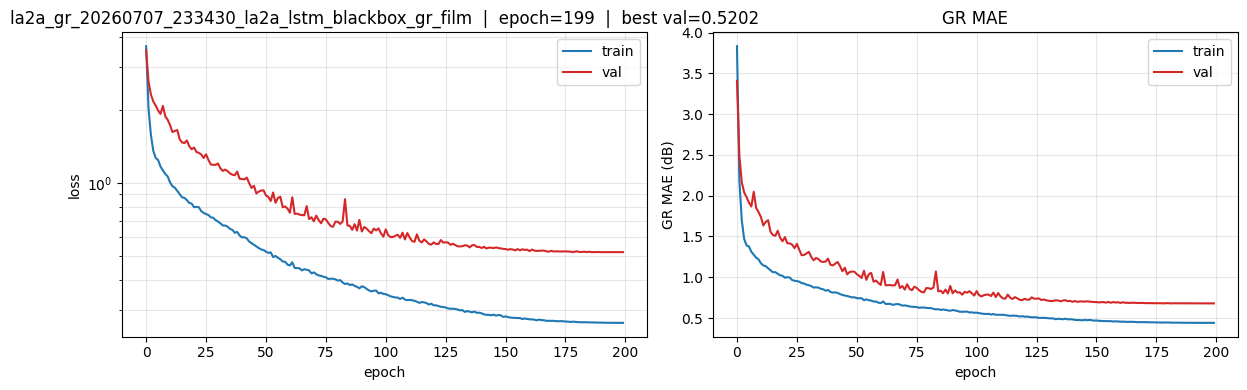

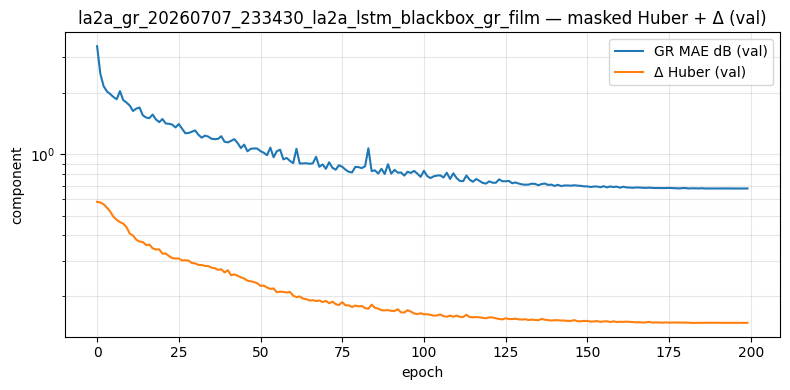

In [5]:
# ── 4. Loss curves (total + MAE / Δ components) ──────────────────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)
    comp_cols = [
        ("mae_db/val", "GR MAE dB (val)"),
        ("delta_db/val", "Δ Huber (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch"); ax.set_ylabel("component"); ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both"); ax.legend()
        ax.set_title(f"{RUN_NAME} — masked Huber + Δ (val)")
        plt.tight_layout(); plt.show()

In [6]:
# ── 5. Checkpoint loading (BlackboxGRLSTM from model_blackbox_gr.py) ──

def load_model_from_ckpt(ckpt_path, hparams_path=None):
    """Build from hparams.json and load weights (strip Lightning 'model.' prefix)."""
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = BlackboxGRLSTM(
        hop_size=int(hp["hop_size"]),
        sample_rate=int(hp["sample_rate"]),
        enc_channels=int(m["enc_channels"]),
        frontend_channels=int(m["frontend_channels"]),
        temporal_kernel=int(m["temporal_kernel"]),
        temporal_dilations=tuple(int(d) for d in m["temporal_dilations"]),
        hidden_size=int(m["hidden_size"]),
        num_controls=int(m["num_controls"]),
        film_order=int(m["film_order"]),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    rf = model.temporal_context + 1
    print(f"Loaded {n_params:,}-param Blackbox-LSTM GR model  "
          f"(hop={model.hop_size}, enc={m['enc_channels']}ch, controls={m['num_controls']}, "
          f"temporal dilations={list(m['temporal_dilations'])}, "
          f"RF {rf} frames ~= {rf * model.hop_size / int(hp['sample_rate']):.2f} s, "
          f"FiLM order={m['film_order']})")
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
SR = int(HP["sample_rate"])
HOP_SIZE = int(HP["hop_size"])
# GR derived from waveforms uses the same 1024-sample causal RMS window the exported
# gr_curves were built with (== dataset_la2a on-the-fly GR).
RMS_WIN = int(HP.get("rms_window", RMS_WINDOW))
WARMUP_FRAMES = int(HP.get("loss", {}).get("warmup_frames", 0))

Loaded 16,121-param Blackbox-LSTM GR model  (hop=256, enc=16ch, controls=2, temporal dilations=[1, 4, 16, 64], RF 256 frames ~= 1.49 s, FiLM order=3)


In [7]:
# ── 6. Prediction & visualisation (GR curve + reconstructed wet) ─────
# LA2A data access: paths by recording id, static knobs [comp_limit, peak_reduction].
# The model predicts a frame-rate GR curve from dry+knobs (cold start = zero
# frame-context = silence); a pre_roll_sec context warms the state before the scored
# segment. Target GR is recomputed on-the-fly from (dry, wet) with a 1023-sample
# lookback (bit-identical to the exported .pt); wet is reconstructed as dry·10^(gr/20).

DEFAULT_PRE_ROLL_SEC = 10.0
LOOKBACK = RMS_WIN - 1


def _params_for(rec) -> torch.Tensor:
    # Normalised static knobs [1, 2] from one recording's setting.
    return torch.tensor(
        normalize_la2a_params(rec["comp_limit"], rec["peak_reduction"]),
        dtype=torch.float32, device=DEVICE,
    ).unsqueeze(0)


def _read_seg_with_gr(rec, start: int, stop: int):
    # dry, gr, wet for [start, stop) as [1, n] tensors. GR recomputed on-the-fly with a
    # 1023-sample lookback so the causal window is filled from real samples.
    read_start = max(0, start - LOOKBACK)
    dry, wet = _read_dry_wet_segment(rec["dry"], rec["wet"], read_start, stop, SR)
    n = min(dry.shape[-1], wet.shape[-1])
    dry, wet = dry[..., :n], wet[..., :n]
    gr = gain_reduction_db(dry, wet, RMS_WIN)
    drop = start - read_start
    return dry[..., drop:], gr[..., drop:], wet[..., drop:]


def _seg_esr(pred: torch.Tensor, wet: torch.Tensor) -> float:
    p, w = pred.flatten(), wet.flatten()
    return float((w - p).pow(2).sum() / (w.pow(2).sum() + 1e-8))


def _default_test_segment_sec(rec) -> float:
    # A segment start inside the recording's TEST region (region start + 30 s, clamped).
    r0, r1 = _region(rec, "test")
    start = min(r0 + int(30 * SR), max(r0, r1 - int(6 * SR)))
    return start / SR


@torch.no_grad()
def predict_gr_segment(rec, start_sec, duration_sec=6.0,
                       pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    if isinstance(rec, int):
        rec = REC_BY_ID[rec]
    start = int(round(start_sec * SR))
    stop = start + int(round(duration_sec * SR))
    context_start = max(0, start - int(round(pre_roll_sec * SR)))
    offset = start - context_start

    dry_ctx, gr_ctx, wet_ctx = _read_seg_with_gr(rec, context_start, stop)
    L = dry_ctx.shape[-1] - (dry_ctx.shape[-1] % model.hop_size)   # whole frames only
    dry_ctx, gr_ctx, wet_ctx = dry_ctx[..., :L], gr_ctx[..., :L], wet_ctx[..., :L]
    params = _params_for(rec)

    gr_fr = model(dry_ctx.unsqueeze(0).to(DEVICE), params)         # [1, 1, T] frame-rate
    gr_pred_db_full = model.to_db(gr_fr, sample_len=L)             # [1, 1, L] dB, clamped
    pred_full = dry_ctx.unsqueeze(0) * torch.pow(10.0, gr_pred_db_full / 20.0)

    seg_len = min(stop - start, L - offset)
    sl = slice(offset, offset + seg_len)
    dry = dry_ctx[..., sl].cpu()
    wet = wet_ctx[..., sl].cpu()
    pred = pred_full[..., sl].squeeze(0).cpu()
    gr_true = gr_ctx[..., sl].clamp(GR_DB_MIN, GR_DB_MAX).squeeze().cpu().numpy()
    gr_pred = gr_pred_db_full[..., sl].squeeze().cpu().numpy()
    gr_err = gr_pred - gr_true
    err = (pred - wet).squeeze().numpy()

    t_len = pred.shape[-1]
    return {
        "id": rec["id"], "comp_limit": rec["comp_limit"], "peak_reduction": rec["peak_reduction"],
        "label": f"id {rec['id']} · cl={rec['comp_limit']} pr={rec['peak_reduction']}",
        "sample_rate": SR, "start_sec": start_sec, "duration_sec": t_len / SR,
        "pre_roll_sec": offset / SR, "time": np.arange(t_len) / SR,
        "dry": dry.squeeze().numpy(), "wet": wet.squeeze().numpy(), "pred": pred.squeeze().numpy(),
        "error": err, "gr_true": gr_true, "gr_pred": gr_pred, "gr_error": gr_err,
        "mae": float(np.mean(np.abs(err))),
        "esr": _seg_esr(pred, wet),
        "gr_mae_db": float(np.mean(np.abs(gr_err))),
        "gr_rmse_db": float(np.sqrt(np.mean(gr_err ** 2))),
    }


def visualize_prediction(rec=None, start_sec=None, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    rec = EVAL_RECS[0] if rec is None else (REC_BY_ID[rec] if isinstance(rec, int) else rec)
    start_sec = _default_test_segment_sec(rec) if start_sec is None else start_sec
    seg = predict_gr_segment(rec, start_sec, duration_sec, pre_roll_sec)

    t = seg["time"]
    # rows: dry | waveform (wet/pred) | GR (true/pred) | GR err
    fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 2, 1]})

    axes[0].plot(t, seg["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, seg["wet"], label="target (wet)", lw=1.0, color="#1f77b4")
    axes[1].plot(t, seg["pred"], label="reconstructed (dry·10^(gr/20))", lw=0.9,
                 color="#d62728", alpha=0.85)
    axes[1].set_ylabel("amp"); axes[1].legend(loc="lower right"); axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, seg["gr_true"], label="target GR", lw=1.4, color="#1f77b4")
    axes[2].plot(t, seg["gr_pred"], label="predicted GR", lw=1.2, color="#d62728", alpha=0.85)
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("GR (dB)"); axes[2].legend(loc="lower right"); axes[2].grid(alpha=0.3)

    axes[3].plot(t, seg["gr_error"], lw=0.8, color="#9467bd")
    axes[3].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[3].set_ylabel("GR err (dB)"); axes[3].set_xlabel("time (s)"); axes[3].grid(alpha=0.3)

    fig.suptitle(title or (
        f"{seg['label']}   (TEST region, {seg['start_sec']:.0f}s)\n"
        f"pre-roll={seg['pre_roll_sec']:.1f}s  MAE {seg['mae']:.4f}  ESR {seg['esr']:.4f}  "
        f"GR MAE={seg['gr_mae_db']:.2f} dB  GR RMSE={seg['gr_rmse_db']:.2f} dB"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return seg

## Usage

Re-run the cells below any time; they read the latest synced run outputs from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(rec=...)` — any recording (an id, or a rec dict); defaults to
  the first recording and a 6 s segment inside its **test** region. Shows the dry input,
  the target vs reconstructed wet, and the predicted vs target GR curve with its error.
- `pr_sweep(comp_limit=0)` — test-region GR curves across a spread of Peak-Reduction
  values (LA2A analog of the diffssl settings sweep; each pr is a **different**
  recording, so the audio differs).
- The split-metrics cells stream every recording's **val** / **test** region on the
  canonical 9-column engine (ported from `06_output/eval_lstm_gain_prior_ws.ipynb`) —
  the model predicts a GR curve, wet is reconstructed as `dry·10^(GR_dB/20)` and scored,
  results duration-weighted and CSV-saved next to the checkpoint. **── 7** scores the
  validation regions, **── 8** the held-out test regions.
- **── 9** prints the headline generalisation number: val→test GR MAE across the whole
  corpus (unseen audio, known settings).

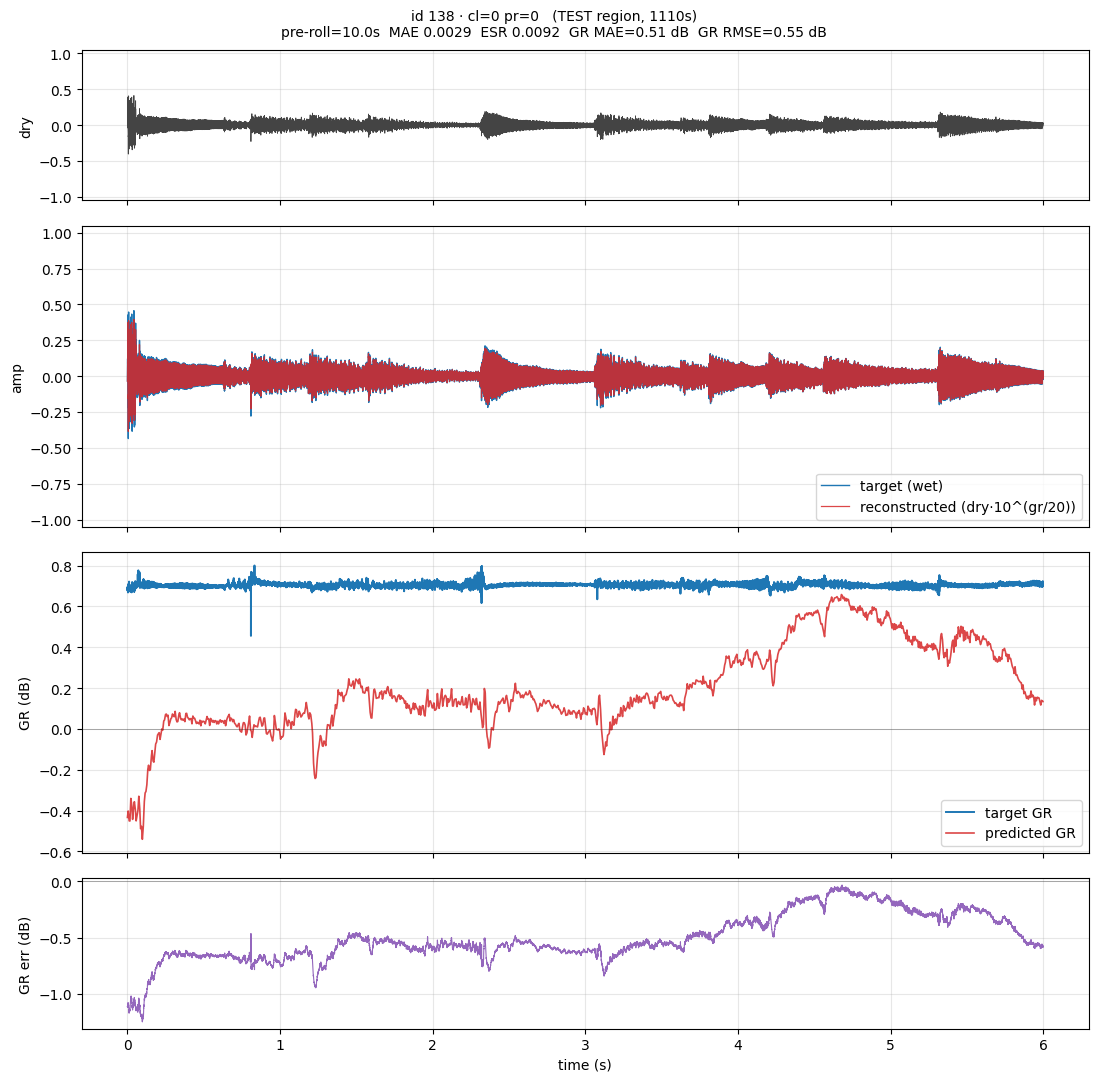

In [8]:
# Single prediction preview — a 6 s segment inside the TEST region of one recording
_ = visualize_prediction(rec=EVAL_RECS[0], duration_sec=6.0)

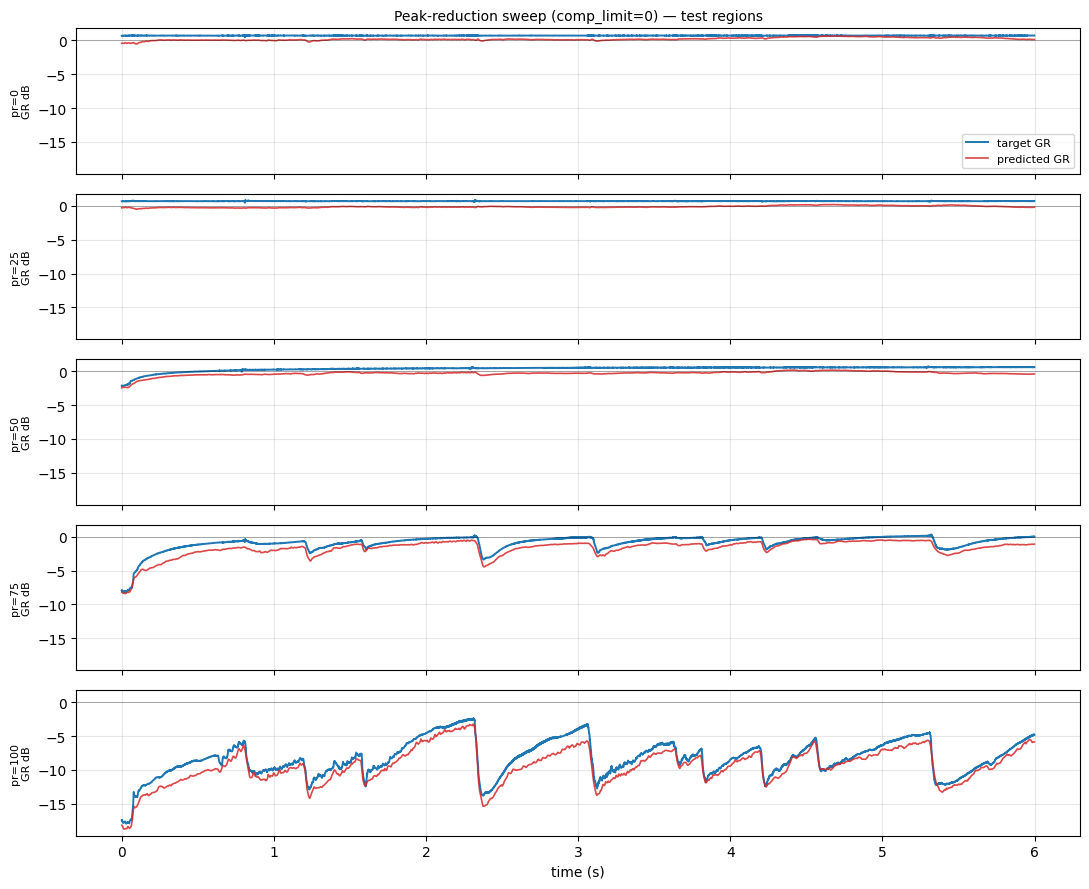

,id,comp_limit,peak_reduction,GR MAE (dB),GR RMSE (dB),MAE,ESR
0,138,0,0,0.505073,0.546664,0.002874,0.009223
1,143,0,25,0.823696,0.835712,0.003650,0.012609
2,148,0,50,0.688642,0.705993,0.003068,0.010248
3,153,0,75,0.782717,0.842720,0.002967,0.013352
4,158,0,100,1.104774,1.241463,0.001956,0.036465


In [9]:
# ── Peak-reduction sweep (LA2A analog of settings_sweep) ─────────────
# Each LA2A setting is a DIFFERENT recording (different audio), so this shows the
# model tracking increasing compression across recordings — not one song reprocessed.
# Picks comp_limit=SWEEP_CL and a spread of Peak-Reduction values, each on a 6 s
# segment inside its own test region.

SWEEP_CL = 0


def pr_sweep(comp_limit=SWEEP_CL, pr_values=(0, 25, 50, 75, 100),
             duration_sec=6.0, pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    recs = []
    for pr in pr_values:
        cand = [r for r in EVAL_RECS if r["comp_limit"] == comp_limit and r["peak_reduction"] == pr]
        if cand:
            recs.append(cand[0])
    segs = [predict_gr_segment(r, _default_test_segment_sec(r), duration_sec, pre_roll_sec)
            for r in recs]

    # Shared GR axis across all panels so panel heights are directly comparable.
    lo = min(float(np.min([s["gr_true"].min(), s["gr_pred"].min()])) for s in segs)
    hi = max(float(np.max([s["gr_true"].max(), s["gr_pred"].max()])) for s in segs)
    pad = 0.05 * max(hi - lo, 1e-3)
    ylim = (lo - pad, hi + pad)

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target GR")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="predicted GR")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylim(*ylim)
        ax.set_ylabel(f"pr={s['peak_reduction']}\nGR dB", fontsize=8)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[0, 0].set_title(f"Peak-reduction sweep (comp_limit={comp_limit}) — test regions", fontsize=10)
    axes[-1, 0].set_xlabel("time (s)")
    plt.tight_layout(); plt.show()

    rows = [{"id": s["id"], "comp_limit": s["comp_limit"], "peak_reduction": s["peak_reduction"],
             "GR MAE (dB)": s["gr_mae_db"], "GR RMSE (dB)": s["gr_rmse_db"],
             "MAE": s["mae"], "ESR": s["esr"]} for s in segs]
    df = pd.DataFrame(rows)
    display(df)
    return segs, df


sweep_segs, sweep_df = pr_sweep()

In [10]:
# ── 6b. Metric engine (ported from 02b_sota_training/eval_lstm_diffssl_tvc.ipynb) ──
#
# The canonical 9-column table so this model drops straight into the cross-model
# comparison. Every moving-average envelope uses an O(N) cumsum window; the FFT
# metrics reimplement auraloss MultiResolutionSTFTLoss and src.losses.{M_SF, EDC},
# batched. MR-STFT and ESR are verified below against nablafx.evaluation (auraloss)
# to <1e-3 / <1e-4.

from scipy.signal import bilinear, lfilter

EPS = 1e-10

# Multi-resolution window / FFT sets (identical to the diffssl_tvc engine)
MR_STE_WINDOWS   = (256, 1024, 4096)
MR_NRMSE_WINDOWS = (512, 1024, 2048)
STFT_SIZES       = (512, 1024, 2048)
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]

# Final metric columns: GR-stage | colour-stage | standard
METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",
    "MR-STFT", "ESR (A-wt)",
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",
]


def _moving_meansq(x_sq, W, centered):
    """Sliding mean of x**2 via prefix sums. centered=symmetric, else causal (trailing)."""
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    """Reference GR trajectory = causal RMS GR (matches src.dsp_torch.gain_reduction_db)."""
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    """Multi-resolution short-time energy distance (envelope shape; Wright & Valimaki)."""
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    """Mean normalised RMS-envelope error (== src.losses.multi_resolution_nrmse, cumsum-fast)."""
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    """auraloss MR-STFT + src.losses {M_SF, EDC} for one (pred, wet) pair."""
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    """The 9 metric columns for one (dry, pred, wet) chunk (float64 1-D arrays)."""
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")

nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [11]:
# ── 7. Region streaming engine + VALIDATION split metrics ────────────
# For every recording, stream its VAL region [.8,.9) in non-overlapping chunks with
# the (lstm_state, frame_context) carried across chunks — exact vs a single full
# forward (the frame encoder is hop-aligned, so hop-multiple chunks tile the frames).
# PRE_ROLL_CHUNKS warm-up chunk(s) warm the state (and fill the GR lookback) but are
# not scored. The model predicts a GR curve; wet is reconstructed as dry·10^(gr/20)
# and each scored chunk goes through the ported 9-column engine, duration-weighted.

MAX_EVAL_RECS: int | None = None       # small int for a smoke test
REGION_EVAL_SEC: float | None = 30.0   # scored seconds per region (None = whole region)
STREAM_CHUNK_SEC = 10.0
PRE_ROLL_CHUNKS = 1                     # warm-up chunks fed before scoring
SAVE_CHUNK_METRICS = False
MIN_METRIC_FRAMES = max(STFT_SIZES)     # skip sub-FFT tail chunks

sr = SR
chunk_samples = max(HOP_SIZE, (int(round(STREAM_CHUNK_SEC * sr)) // HOP_SIZE) * HOP_SIZE)


def _region_buffer(rec, split):
    # dry/wet for [ctx, score_end) where ctx = region_start − warm-up. `warm` is how
    # many leading samples are warm-up (not scored).
    r0, r1 = _region(rec, split)
    score_end = r1 if REGION_EVAL_SEC is None else min(r1, r0 + int(round(REGION_EVAL_SEC * sr)))
    ctx = max(0, r0 - PRE_ROLL_CHUNKS * chunk_samples)
    dry_b, _gr_b, wet_b = _read_seg_with_gr(rec, ctx, score_end)
    return dry_b, wet_b, (r0 - ctx)


@torch.no_grad()
def _stream_buffer(dry_b, wet_b, warm, params):
    # Stateful chunked GR prediction over one region buffer; per-chunk metric rows for
    # the scored part. wet reconstructed as dry·10^(gr_pred/20).
    state, rows, N = None, [], dry_b.shape[-1]
    for o in range(0, N, chunk_samples):
        stop = min(o + chunk_samples, N)
        d, w = dry_b[..., o:stop], wet_b[..., o:stop]
        L = d.shape[-1] - (d.shape[-1] % HOP_SIZE)   # whole frames only
        if L == 0:
            continue
        d, w = d[..., :L], w[..., :L]
        gr_fr, state = MODEL(d.unsqueeze(0).to(DEVICE), params, state, return_state=True)
        gr_db = MODEL.to_db(gr_fr, sample_len=L)                    # [1, 1, L]
        pred = d.unsqueeze(0) * torch.pow(10.0, gr_db / 20.0)
        if o < warm:                       # warm-up region — feed but don't score
            continue
        if L < MIN_METRIC_FRAMES:
            continue
        rows.append({"Start (s)": o / sr, "Duration (s)": L / sr, "Frames": L,
                     **chunk_metrics(d.squeeze(0).double().cpu().numpy(),
                                     pred.squeeze().double().cpu().numpy(),
                                     w.squeeze(0).double().cpu().numpy())})
    return rows


def stream_split_metrics(split, recs):
    chunk_rows, rec_rows = [], []
    for i, rec in enumerate(recs, start=1):
        print(f"[{split} {i}/{len(recs)}] id {rec['id']}  cl={rec['comp_limit']} pr={rec['peak_reduction']}")
        buf = _region_buffer(rec, split)
        rows = _stream_buffer(*buf, _params_for(rec))
        chunk_rows += [{"Id": rec["id"], "comp_limit": rec["comp_limit"],
                        "peak_reduction": rec["peak_reduction"], **r} for r in rows]
        rec_rows.append({"Split": split, "Id": rec["id"], "comp_limit": rec["comp_limit"],
                         "peak_reduction": rec["peak_reduction"],
                         "Duration (s)": sum(r["Frames"] for r in rows) / sr,
                         **_weighted_average_metric_rows(rows, METRIC_COLS)})
        gc.collect()
    total = sum(r["Frames"] for r in chunk_rows)
    split_row = {"Split": split, "Recordings": len(recs), "Chunks": len(chunk_rows),
                 "Duration (s)": total / sr, **_weighted_average_metric_rows(chunk_rows, METRIC_COLS)}
    return pd.DataFrame(rec_rows), pd.DataFrame([split_row]), chunk_rows


_val_recs = EVAL_RECS if MAX_EVAL_RECS is None else EVAL_RECS[:MAX_EVAL_RECS]
val_pair_metrics_df, val_audio_metrics_df, val_chunk_rows = stream_split_metrics("val", _val_recs)

val_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_pairs.csv", index=False)
val_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(val_chunk_rows).to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_validation(.csv, _pairs.csv)")

display(val_pair_metrics_df)
display(val_audio_metrics_df)

[val 1/84] id 138  cl=0 pr=0
[val 2/84] id 139  cl=0 pr=5
[val 3/84] id 140  cl=0 pr=10
[val 4/84] id 141  cl=0 pr=15
[val 5/84] id 142  cl=0 pr=20
[val 6/84] id 143  cl=0 pr=25
[val 7/84] id 144  cl=0 pr=30
[val 8/84] id 145  cl=0 pr=35
[val 9/84] id 146  cl=0 pr=40
[val 10/84] id 147  cl=0 pr=45
[val 11/84] id 148  cl=0 pr=50
[val 12/84] id 149  cl=0 pr=55
[val 13/84] id 150  cl=0 pr=60
[val 14/84] id 151  cl=0 pr=65
[val 15/84] id 152  cl=0 pr=70
[val 16/84] id 153  cl=0 pr=75
[val 17/84] id 154  cl=0 pr=80
[val 18/84] id 155  cl=0 pr=85
[val 19/84] id 156  cl=0 pr=90
[val 20/84] id 157  cl=0 pr=95
[val 21/84] id 158  cl=0 pr=100
[val 22/84] id 159  cl=1 pr=0
[val 23/84] id 160  cl=1 pr=5
[val 24/84] id 161  cl=1 pr=10
[val 25/84] id 162  cl=1 pr=15
[val 26/84] id 163  cl=1 pr=20
[val 27/84] id 164  cl=1 pr=25
[val 28/84] id 165  cl=1 pr=30
[val 29/84] id 166  cl=1 pr=35
[val 30/84] id 167  cl=1 pr=40
[val 31/84] id 168  cl=1 pr=45
[val 32/84] id 169  cl=1 pr=50
[val 33/84] id 170  

,Split,Id,comp_limit,peak_reduction,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,val,138,0,0,29.988571,0.767394,0.159739,0.601341,0.012960,0.009281,0.000164,0.114246,0.087746,0.111825
1,val,139,0,5,29.988571,0.776100,0.162127,0.607154,0.013261,0.009409,0.000166,0.090609,0.088859,0.113612
2,val,140,0,10,29.988571,0.760958,0.160433,0.607976,0.013089,0.009369,0.000164,0.083030,0.087794,0.112704
3,val,141,0,15,29.988571,0.740916,0.156964,0.603876,0.012602,0.009257,0.000159,0.079477,0.085747,0.110918
4,val,142,0,20,29.988571,0.725308,0.155549,0.604439,0.012101,0.009113,0.000156,0.078099,0.084564,0.109615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,val,259,1,80,29.988571,1.881433,0.418984,1.213963,0.122289,0.027166,0.001557,0.148554,0.273825,0.456590
80,val,260,1,85,29.988571,2.093915,0.468570,1.287234,0.182442,0.022060,0.001021,0.121574,0.301567,0.509044
81,val,261,1,90,29.988571,2.593441,0.557824,1.394562,0.286883,0.021239,0.000886,0.300602,0.356087,0.581488
82,val,262,1,95,29.988571,2.373753,0.535624,1.352227,0.336151,0.017433,0.000656,0.153508,0.348604,0.625183


,Split,Recordings,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,val,84,252,2513.049252,1.416863,0.291525,0.933421,0.06466,0.033978,0.004788,0.123448,0.184866,0.267026


## Held-out TEST split (final region of every recording)

The **test** split is the last `[.9, 1.0)` fraction of **every** recording — audio the
model never saw, at the same 42 settings it was trained on (LA2A's temporal-split
convention). Same stateful region streaming and same 9-column engine as the validation
cell; only the region differs. This is the headline generalisation number (unseen
audio, known settings). There is no separate external `test_ground_truth/` set for LA2A
— the SignalTrain corpus is a flat pool of recordings, not a song × setting grid.

In [12]:
# ── 8. Audio metrics on the TEST split ───────────────────────────────

_test_recs = EVAL_RECS if MAX_EVAL_RECS is None else EVAL_RECS[:MAX_EVAL_RECS]
test_pair_metrics_df, test_audio_metrics_df, test_chunk_rows = stream_split_metrics("test", _test_recs)

test_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_pairs.csv", index=False)
test_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(test_chunk_rows).to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_test(.csv, _pairs.csv)")

display(test_pair_metrics_df)
display(test_audio_metrics_df)

[test 1/84] id 138  cl=0 pr=0
[test 2/84] id 139  cl=0 pr=5
[test 3/84] id 140  cl=0 pr=10
[test 4/84] id 141  cl=0 pr=15
[test 5/84] id 142  cl=0 pr=20
[test 6/84] id 143  cl=0 pr=25
[test 7/84] id 144  cl=0 pr=30
[test 8/84] id 145  cl=0 pr=35
[test 9/84] id 146  cl=0 pr=40
[test 10/84] id 147  cl=0 pr=45
[test 11/84] id 148  cl=0 pr=50
[test 12/84] id 149  cl=0 pr=55
[test 13/84] id 150  cl=0 pr=60
[test 14/84] id 151  cl=0 pr=65
[test 15/84] id 152  cl=0 pr=70
[test 16/84] id 153  cl=0 pr=75
[test 17/84] id 154  cl=0 pr=80
[test 18/84] id 155  cl=0 pr=85
[test 19/84] id 156  cl=0 pr=90
[test 20/84] id 157  cl=0 pr=95
[test 21/84] id 158  cl=0 pr=100
[test 22/84] id 159  cl=1 pr=0
[test 23/84] id 160  cl=1 pr=5
[test 24/84] id 161  cl=1 pr=10
[test 25/84] id 162  cl=1 pr=15
[test 26/84] id 163  cl=1 pr=20
[test 27/84] id 164  cl=1 pr=25
[test 28/84] id 165  cl=1 pr=30
[test 29/84] id 166  cl=1 pr=35
[test 30/84] id 167  cl=1 pr=40
[test 31/84] id 168  cl=1 pr=45
[test 32/84] id 169 

,Split,Id,comp_limit,peak_reduction,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,138,0,0,29.988571,0.814204,0.199869,0.510417,0.030402,0.021865,0.002436,0.147431,0.129486,0.149242
1,test,139,0,5,29.988571,0.814018,0.198615,0.512694,0.030084,0.021870,0.002428,0.165119,0.129390,0.149634
2,test,140,0,10,29.988571,0.808093,0.195228,0.511431,0.029513,0.021750,0.002422,0.172651,0.127316,0.147670
3,test,141,0,15,29.988571,0.792216,0.189649,0.507570,0.028781,0.021491,0.002409,0.169688,0.123983,0.144058
4,test,142,0,20,29.988571,0.775192,0.183881,0.504124,0.028201,0.021244,0.002387,0.155449,0.120815,0.141359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,test,259,1,80,29.988571,1.970221,0.402710,1.265555,0.126899,0.026976,0.001507,0.122412,0.263292,0.434808
80,test,260,1,85,29.988571,2.020220,0.452508,1.326148,0.164039,0.022719,0.001045,0.125776,0.290173,0.497138
81,test,261,1,90,29.988571,2.384383,0.501548,1.329816,0.244724,0.018730,0.000690,0.209827,0.318485,0.566801
82,test,262,1,95,29.988571,2.614469,0.511640,1.413462,0.353325,0.018084,0.000649,0.282324,0.334073,0.608114


,Split,Recordings,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,84,252,2513.049252,1.396913,0.296727,0.881842,0.066357,0.038975,0.005694,0.128026,0.197805,0.277837


## 9. Generalisation summary — val → test GR MAE

The single number this predictor exists to produce: the GR MAE on **validation** regions
(`[.8,.9)`, unseen audio at known settings) next to the **test** regions (`[.9,1)`). A
small val→test gap means the learned frontend is estimating gain reduction from *level*,
not leaking recording-specific timbre — the property the `05_conditioning` detector-vs-
blackbox ablation measures on diffssl. Reads the split CSVs written by ── 7 / ── 8.

In [13]:
# ── 9. val → test GR MAE gap ─────────────────────────────────────────

def _split_row(fn):
    p = Path(RUN_DIR) / fn
    return pd.read_csv(p).iloc[0] if p.is_file() else None


_val = _split_row("eval_audio_metrics_validation.csv")
_test = _split_row("eval_audio_metrics_test.csv")

rows = []
for name, r in (("validation", _val), ("test", _test)):
    if r is not None:
        rows.append({"Split": name, **{c: float(r[c]) for c in METRIC_COLS if c in r},
                     "Duration (s)": float(r.get("Duration (s)", float("nan")))})
summary_df = pd.DataFrame(rows)
display(summary_df)

if _val is not None and _test is not None:
    gap = float(_test["GR MAE (dB)"]) - float(_val["GR MAE (dB)"])
    print(f"GR MAE  val={float(_val['GR MAE (dB)']):.3f} dB  "
          f"test={float(_test['GR MAE (dB)']):.3f} dB  "
          f"→ val→test gap = {gap:+.3f} dB")

,Split,GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF,Duration (s)
0,validation,1.416863,0.291525,0.933421,0.064660,0.033978,0.004788,0.123448,0.184866,0.267026,2513.049252
1,test,1.396913,0.296727,0.881842,0.066357,0.038975,0.005694,0.128026,0.197805,0.277837,2513.049252


GR MAE  val=1.417 dB  test=1.397 dB  → val→test gap = -0.020 dB
